# 01 -- HMC symbolic tightness

## 0. Colab bootstrap (no-op locally)

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    import sys, os
    PROJECT_ROOT = '/content/drive/MyDrive/Master-thesis'
    if PROJECT_ROOT not in sys.path:
        sys.path.insert(0, PROJECT_ROOT)
    os.chdir(PROJECT_ROOT + '/notebooks')
    print('Colab setup done -- cwd:', os.getcwd())
except ImportError:
    print('Local run -- Colab bootstrap skipped')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Colab setup done -- cwd: /content/drive/MyDrive/Master-thesis/notebooks


## 1. Setup

In [2]:
import json
import os
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'mnlearn').is_dir():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('could not locate project root')
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)

from mnlearn.baselines import ForwardBackwardClassifier
from mnlearn.config import load_config
from mnlearn.data import load_hmc_benchmark
from mnlearn.experiments import collect_results
from mnlearn.learning import hamming_loss, train

RUN_TAG    = 'hmc_sym_tightness'
RESULTS    = REPO_ROOT / 'results' / RUN_TAG
THESIS_FIG = REPO_ROOT / 'thesis' / 'figures' / RUN_TAG
THESIS_TBL = REPO_ROOT / 'thesis' / 'tables'
THESIS_FIG.mkdir(parents=True, exist_ok=True)
THESIS_TBL.mkdir(parents=True, exist_ok=True)

## 2. Sweep

In [3]:
SEEDS  = [0, 1, 2]
LOSSES = ['m3n_hinge', 'lp_m3n']

BASE_CONFIGS = {
    'm3n_hinge': load_config(REPO_ROOT / 'configs' / 'experiments' / 'm3n_hinge_hmc_symbolic.yaml'),
    'lp_m3n':    load_config(REPO_ROOT / 'configs' / 'experiments' / 'lpm3n_hmc_symbolic.yaml'),
}

def run_name(loss: str, seed: int) -> str:
    return f'{RUN_TAG}/{loss}_seed{seed}'

def make_cfg(loss: str, seed: int):
    base = BASE_CONFIGS[loss]
    return replace(
        base,
        experiment=replace(base.experiment, name=run_name(loss, seed), seed=seed),
    )

## 3. Run

In [4]:
for loss in LOSSES:
    for seed in SEEDS:
        cfg = make_cfg(loss, seed)
        out = REPO_ROOT / 'results' / cfg.experiment.name
        if (out / 'results.json').exists():
            print(f'skip (already ran): {cfg.experiment.name}')
            continue
        print(f'running: {cfg.experiment.name}')
        train(cfg)

print('\ndone.')

running: hmc_sym_tightness/m3n_hinge_seed0
running: hmc_sym_tightness/m3n_hinge_seed1
running: hmc_sym_tightness/m3n_hinge_seed2
running: hmc_sym_tightness/lp_m3n_seed0
running: hmc_sym_tightness/lp_m3n_seed1
running: hmc_sym_tightness/lp_m3n_seed2

done.


## 4. Forward-Backward baseline

In [5]:
hmc_meta = json.loads((REPO_ROOT / 'benchmarks' / 'hmc' / 'config.json').read_text())
K       = hmc_meta['num_states']
p_self  = hmc_meta['p_self']
p_emit  = hmc_meta['p_emit']
N_TEST  = BASE_CONFIGS['m3n_hinge'].data.test_size

bench = load_hmc_benchmark(str(REPO_ROOT / 'benchmarks' / 'hmc'), mode='symbolic')
test_X, test_Y = bench['test'].get_all_tensors()
test_X, test_Y = test_X[:N_TEST], test_Y[:N_TEST]

fb = ForwardBackwardClassifier(num_states=K, p_self=p_self, p_emit=p_emit)
fb_hamming = hamming_loss(fb.predict(test_X), test_Y)
print(f'FB Bayes-optimal Hamming: {fb_hamming:.4f}')

FB Bayes-optimal Hamming: 0.2284


## 5. Tightness table

In [6]:
df = collect_results(str(RESULTS / '*_seed*/'))
df = df[df['loss'].isin(LOSSES)].copy()

tightness = (
    df.groupby('loss')['hamming']
      .agg(['mean', 'std', 'count'])
      .reset_index()
)
tightness.loc[len(tightness)] = ['FB (Bayes optimal)', fb_hamming, 0.0, 1]
print(tightness.to_string(index=False))

tightness.to_csv(THESIS_TBL / 's5_2_1_tightness.csv', index=False)

              loss     mean      std  count
            lp_m3n 0.243977 0.000609      3
         m3n_hinge 0.238114 0.000856      3
FB (Bayes optimal) 0.228400 0.000000      1


## 6. Validation Hamming curves

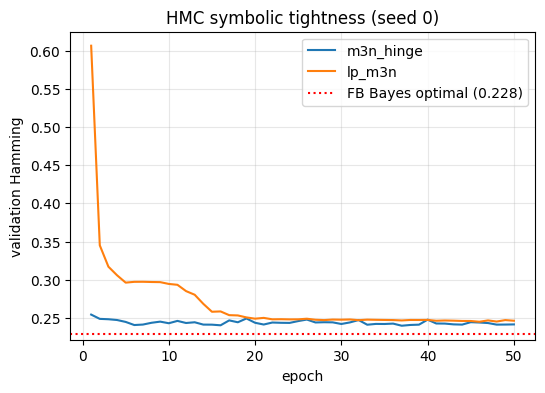

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

for loss in LOSSES:
    cfg = make_cfg(loss, SEEDS[0])
    history = json.loads((REPO_ROOT / 'results' / cfg.experiment.name / 'history.json').read_text())
    val_h = [m['hamming'] for m in history['val_metrics']]
    ax.plot(history['epoch'], val_h, label=loss)

ax.axhline(fb_hamming, color='red', linestyle=':',
           label=f'FB Bayes optimal ({fb_hamming:.3f})')
ax.set_xlabel('epoch')
ax.set_ylabel('validation Hamming')
ax.set_title(f'HMC symbolic tightness (seed {SEEDS[0]})')
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(THESIS_FIG / 'tightness.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Learned pairwise weights

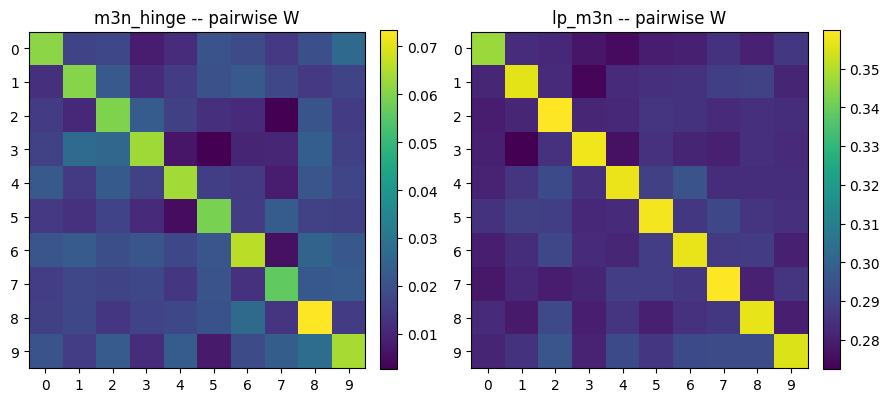

In [8]:
pairwise = {}
for loss in LOSSES:
    cfg = make_cfg(loss, SEEDS[0])
    sd  = torch.load(
        REPO_ROOT / 'results' / cfg.experiment.name / 'model.pt',
        weights_only=True,
    )
    pairwise[loss] = sd['pairwise'].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, loss in zip(axes, LOSSES):
    W = pairwise[loss]
    im = ax.imshow(W, cmap='viridis', vmin=W.min(), vmax=W.max())
    ax.set_title(f'{loss} -- pairwise W')
    ax.set_xticks(range(W.shape[1]))
    ax.set_yticks(range(W.shape[0]))
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(THESIS_FIG / 'learned_weights.png', bbox_inches='tight', dpi=150)
plt.show()